Лабораторна робота No4. Метод k найближчих сусідів

In [63]:
import pandas as pd
df = pd.read_csv("ЛР4-пгр2.csv", sep=";")
df.shape

(1599, 12)

In [64]:
df.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [65]:
from sklearn.model_selection import ShuffleSplit

X = df.drop(columns=df.columns[-1])  
y = df[df.columns[-1]]              

ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Перетворимо на список індексів 
splits = list(ss.split(X))

train_idx, test_idx = splits[7]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Навчальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)

Навчальна вибірка: (1279, 11)
Тестова вибірка: (320, 11)


In [66]:

print("Розподіл цільової змінної у train:")
print(y_train.value_counts())

print("Розподіл цільової змінної у test:")
print(y_test.value_counts())

Розподіл цільової змінної у train:
quality
5    552
6    512
7    153
4     40
8     14
3      8
Name: count, dtype: int64
Розподіл цільової змінної у test:
quality
5    129
6    126
7     46
4     13
8      4
3      2
Name: count, dtype: int64


In [67]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier()  #(n_neighbors=6)

model_knn.fit(X_train, y_train)

# базовп точність на тестовій вибірці
accuracy = model_knn.score(X_test, y_test)
print(f"Точність на тестовій вибірці: {accuracy:.4f}")

Точність на тестовій вибірці: 0.5156


Класифікаційний звіт для тренувальної вибірки:
              precision    recall  f1-score   support

           3       1.00      0.25      0.40         8
           4       0.38      0.12      0.19        40
           5       0.68      0.80      0.74       552
           6       0.66      0.69      0.68       512
           7       0.71      0.42      0.53       153
           8       0.00      0.00      0.00        14

    accuracy                           0.67      1279
   macro avg       0.57      0.38      0.42      1279
weighted avg       0.66      0.67      0.66      1279

Класифікаційний звіт для тестової вибірки:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        13
           5       0.55      0.69      0.61       129
           6       0.48      0.49      0.49       126
           7       0.52      0.30      0.38        46
           8       0.00      0.00      0.0

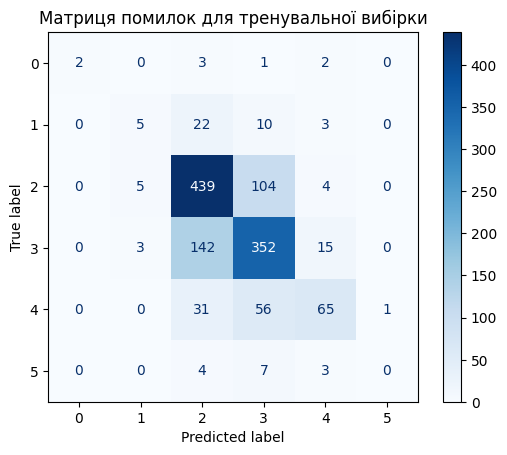

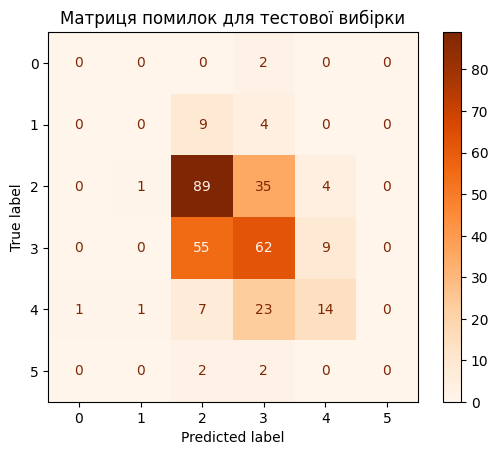

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning
import warnings
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)


# Передбачення для train та test
y_train_pred = model_knn.predict(X_train)
y_test_pred = model_knn.predict(X_test)

# Класифікаційний звіт для train
print("Класифікаційний звіт для тренувальної вибірки:")
print(classification_report(y_train, y_train_pred))

# Класифікаційний звіт для test
print("Класифікаційний звіт для тестової вибірки:")
print(classification_report(y_test, y_test_pred))

# Матриця помилок для train
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Матриця помилок для тренувальної вибірки")
plt.show()

# Матриця помилок для test
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Oranges')
plt.title("Матриця помилок для тестової вибірки")
plt.show()


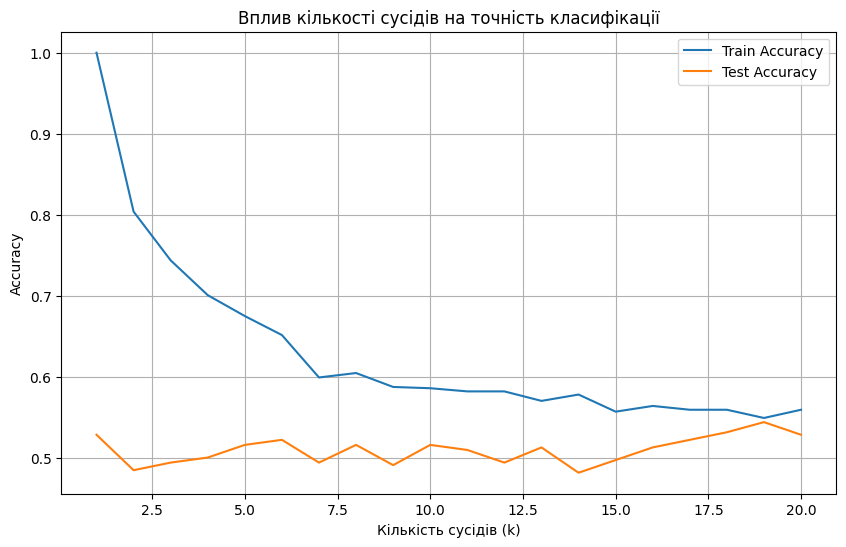

In [69]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_accuracy = []
test_accuracy = []


for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
 
    y_train_pred = knn.predict(X_train)
    train_accuracy.append(accuracy_score(y_train, y_train_pred))
  
    y_test_pred = knn.predict(X_test)
    test_accuracy.append(accuracy_score(y_test, y_test_pred))

# Побудова графіку
plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), train_accuracy, label='Train Accuracy')
plt.plot(range(1, 21), test_accuracy,  label='Test Accuracy')
plt.xlabel("Кількість сусідів (k)")
plt.ylabel("Accuracy")
plt.title("Вплив кількості сусідів на точність класифікації")
plt.legend()
plt.grid(True)
plt.show()
